In [ ]:
import os
import torch
import gc
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/LDMX_GNN/GAIN')

2.11.0+cpu
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mounted at /content/drive


In [ ]:
from time import time
import copy
import math

import torch
import torch_geometric
import GNNTrackingTools as GTT
import models

from torch import optim
from torch.optim.lr_scheduler import StepLR
import torch.nn.functional as F
from torch.utils.data import random_split

from torch_geometric.data import Data, DataLoader, InMemoryDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import sklearn
import inspect

# Load trained model

In [ ]:
run = 1

In [ ]:
tracker_name = 'Recoil' # Either 'Tagger' or 'Recoil'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [ ]:
# Initialize model
hidden_size = 58

model = models.MyIN_small(hidden_size).to(device)

total_trainable_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_trainable_params}")

model.load_state_dict(torch.load('/content/drive/MyDrive/LDMX_GNN/data/state_dicts/IN2_amb_'+tracker_name+'_signal_state_dict_'+str(run)+'.pt'))


Total trainable parameters: 48203


<All keys matched successfully>

# Test on 1.0 GeV A'

In [ ]:
in_dir = '/content/drive/MyDrive/LDMX_GNN/data/signal_processed/test/signal_Ap1.0GeV_1e_processed/'
df = GTT.load_pickle_files_to_dataframe(in_dir)
df['SignalID'] = df.apply(GTT.get_signal_recoilID, axis=1)
df['TruthP'] = df.apply(GTT.get_signal_recoilP, axis=1)

# Currently the ldmx-sw digitization processor outputs full 3D info
# Strip ambiguities must be added manually for consistency with CKF
df = GTT.add_strip_ambiguities(df, tracker_name)

In [ ]:


# Compute Info needed to build graphs
# GetGraphInfo requires two arguments: The number of primaries simulated and the tracker name (either 'Tagger' or 'Recoil')
df_graph = pd.DataFrame()
df_graph[['edge_index_0', 'edge_index_1', 'edge_feat_0', 'edge_feat_1', 'edge_feat_2','edge_label']]= df.apply(GTT.GetGraphInfo, axis=1, args=(tracker_name,), result_type='expand')
df_graph['SignalID'] = df['SignalID']
df_graph['TruthP'] = df['TruthP']
df_graph['Digi_x'] = df[f'{tracker_name}_Digi_x']
df_graph['Digi_y'] = df[f'{tracker_name}_Digi_y']
df_graph['Digi_z'] = df[f'{tracker_name}_Digi_z']
df_graph['Digi_trackID'] = df[f'{tracker_name}_Digi_trackID']

# Free up some RAM
del df
gc.collect()

/content/drive/MyDrive/LDMX_GNN/GAIN/GNNTrackingTools.py:160: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.Tensor([self.df.Digi_x[idx], self.df.Digi_y[idx], self.df.Digi_z[idx]]).T


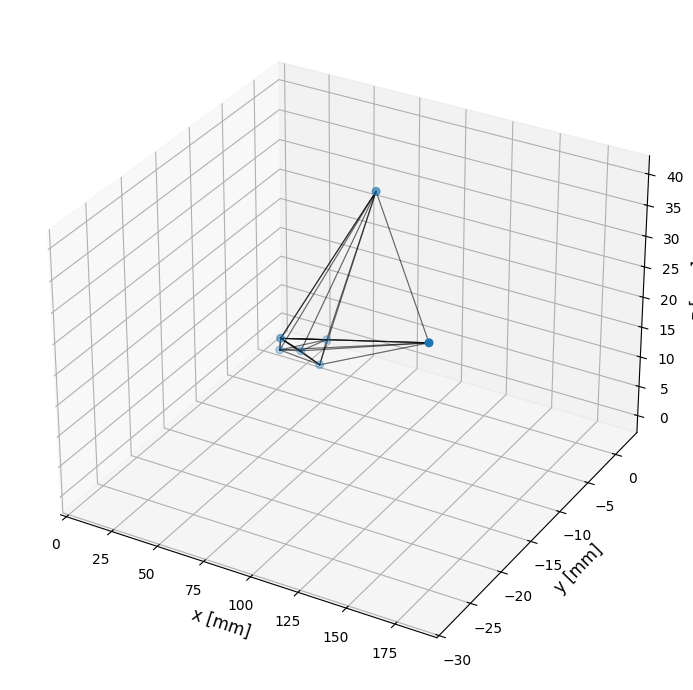

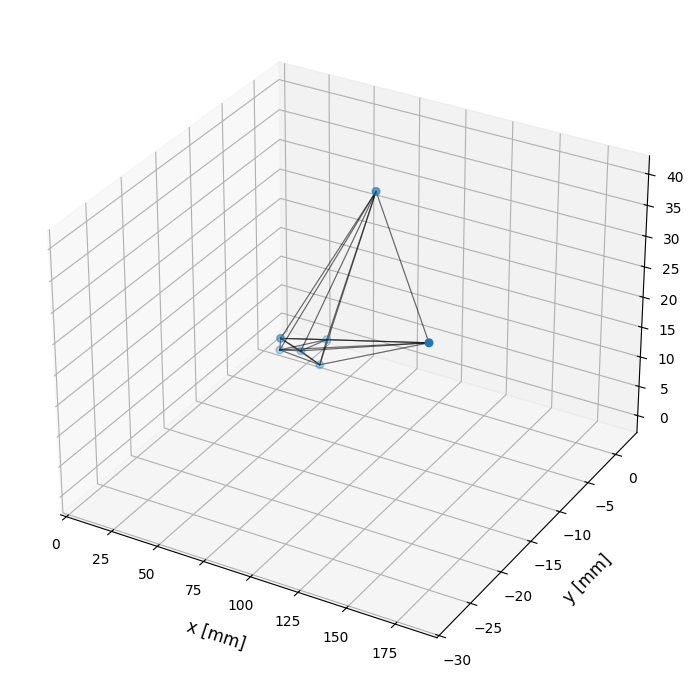

In [ ]:
# Make GNN dataset
dataset = GTT.MyInMemoryDataset(df_graph, tracker = tracker_name)

# Plot example graph
data = dataset[17]
GTT.plot_pyg_graph_3d(data, plot_truth=True)

In [ ]:
# Make DataLoaders
batch_size = 128
test_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

test_loss, test_acc, test_TPR, test_TNR, labels, preds = GTT.test(model, device, test_loader)

print("test loss = ", test_loss)
print("test acc = ", test_acc)
print("test TPR = ", test_TPR)
print("test TNR = ", test_TNR)


/tmp/ipykernel_7247/4224904055.py:3: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)


test loss =  0.05678096952563299
test acc =  0.9772456423907802
test TPR =  0.9831353563812796
test TNR =  0.9584739955076507


Test AUROC: 0.99746489


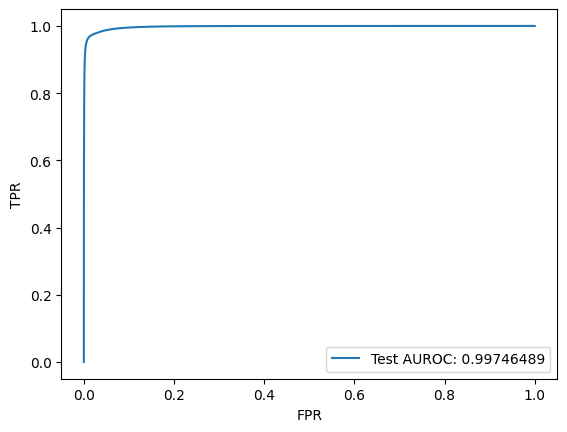

In [ ]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(labels, preds, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.8f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.8f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

In [ ]:
brier = sklearn.metrics.brier_score_loss(labels, preds)
print(f'Brier score: {brier:0.8f}')

Brier score: 0.01634879


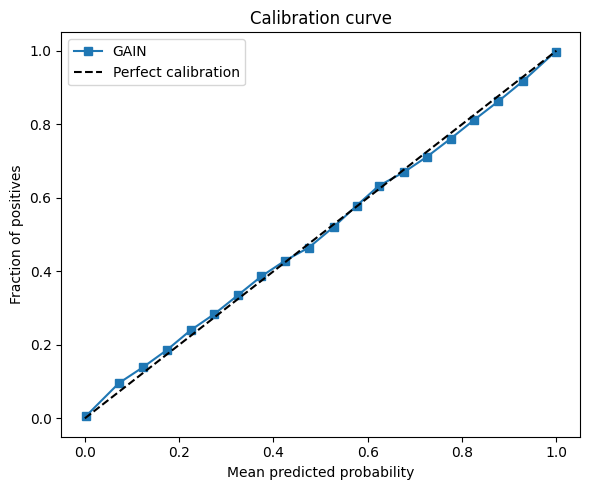

In [ ]:
from sklearn.calibration import calibration_curve

fraction_of_positives, mean_predicted_value = calibration_curve(labels, preds, n_bins=20, strategy='uniform')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(mean_predicted_value, fraction_of_positives, 's-', label='GAIN')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration curve')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Expected Calibration Error (equal-frequency bins)
preds_arr  = np.array(preds)
labels_arr = np.array(labels)
n_bins = 20
bin_edges = np.quantile(preds_arr, np.linspace(0, 1, n_bins + 1))
bin_edges = np.unique(bin_edges)
bin_edges[-1] = np.nextafter(bin_edges[-1], np.inf)  # include max value
ece = 0.0
n_total = len(preds_arr)
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (preds_arr >= lo) & (preds_arr < hi)
    if mask.sum() == 0:
        continue
    bin_conf = preds_arr[mask].mean()
    bin_acc  = labels_arr[mask].mean()
    ece += (mask.sum() / n_total) * abs(bin_conf - bin_acc)
print(f'ECE: {ece:.6f}')

ECE: 0.002122


# Test on all A' massess

In [ ]:
# Minimum hits to construct a track, this should match whats used in TruthSeedProcessor (7 for Recoil tracker, 11 for Tagger tracker)
min_nodes = 7
# Threshold used for absolute edge labeling
thres = 0.5
# Fraction of hits in a GNN track belonging to a single truth track needed to match the,
match_frac = 0.5


dfs = []



for Apm in [0.001, 0.01, 0.1, 1.0]:
    in_dir = '/content/drive/MyDrive/LDMX_GNN/data/signal_processed/test/signal_Ap'+str(Apm)+'GeV_1e_processed/'
    df = GTT.load_pickle_files_to_dataframe(in_dir)
    df['SignalID'] = df.apply(GTT.get_signal_recoilID, axis=1)
    df['TruthP'] = df.apply(GTT.get_signal_recoilP, axis=1)

    # Currently the ldmx-sw digitization processor outputs full 3D info
    # Strip ambiguities must be added manually for consistency with CKF
    df = GTT.add_strip_ambiguities(df, tracker_name)

    # Compute Info needed to build graphs
    # GetGraphInfo requires two arguments: The number of primaries simulated and the tracker name (either 'Tagger' or 'Recoil')
    df_graph = pd.DataFrame()
    df_graph[['edge_index_0', 'edge_index_1', 'edge_feat_0', 'edge_feat_1', 'edge_feat_2','edge_label']]= df.apply(GTT.GetGraphInfo, axis=1, args=(tracker_name,), result_type='expand')
    df_graph['SignalID'] = df['SignalID']
    df_graph['TruthP'] = df['TruthP']
    df_graph['Digi_x'] = df[f'{tracker_name}_Digi_x']
    df_graph['Digi_y'] = df[f'{tracker_name}_Digi_y']
    df_graph['Digi_z'] = df[f'{tracker_name}_Digi_z']
    df_graph['Digi_trackID'] = df[f'{tracker_name}_Digi_trackID']

    # Free up some ram
    del df
    gc.collect()

    dataset = GTT.MyInMemoryDataset(df_graph, tracker = tracker_name)

    test_loader = DataLoader(dataset, batch_size=1, shuffle=False)

    Truth_Ps = []
    Nhits = []
    matched_tracks = []
    num_GNN_Tracks = []


    # Check how many parameters the model's forward method takes
    # If it's 4, the model take Edep as input feature
    Nparams = len(inspect.signature(model.forward).parameters)

    model.eval()
    with torch.no_grad():
        for batch_idx, data in enumerate(test_loader):

            # Move datat to device
            data = data.to(device)

            # GNN inference - depends on whether Edep is used
            if Nparams == 4:
                output = model(data.x, data.Edep, data.edge_index, data.edge_attr)
            else:
                output = model(data.x, data.edge_index, data.edge_attr)

            data = data.cpu()
            output = output.cpu()

            # Use GNN prediction to create track candidates via connected_components
            y_pred =  output.reshape(-1)>thres
            data.edge_index = data.edge_index[:,y_pred]
            tracks = data.connected_components()

            # Keep only tracks passing min_nodes requirement
            rm_idx = []
            for index, track in enumerate(tracks):
                if track.x.shape[0] <  min_nodes:
                    rm_idx += [index]
            for i in sorted(rm_idx, reverse=True):
                del tracks[i]

            track_filter = data.truthID == data.SignalID[0]
            truth_track = data.x[track_filter]
            Nhits += [truth_track.shape[0]]
            Truth_Ps += [data.truthP[0].item()]

            num_GNN_Tracks += [len(tracks)]
            n_matched = 0
            if truth_track.shape[0] > 0:
                for index, track in enumerate(tracks):

                    # Find fraction of the GNN track that is contained in the truth track
                    matches = (track.x[:, None, :] == truth_track[None, :, :]).all(dim=2).any(dim=1)
                    count = matches.sum().item()

                    # Tracks are matched based on the fraction of shared hits
                    # This could be calculated as [matched hits] / [hits in GNN track] or [matched hits] / [hits in truth track]
                    # By taking the minimum, I use whichever requirement is more strict
                    frac_contained1 = count/truth_track.shape[0]
                    frac_contained2 = count/track.x.shape[0]
                    frac_contained = np.minimum(frac_contained1,frac_contained2)

                    if frac_contained >= match_frac:
                        n_matched += 1
                        break

            matched_tracks += [n_matched]


    # Create the DataFrame
    df_results = pd.DataFrame({
        'Truth_Ps': Truth_Ps,
        'Nhits': Nhits,
        'matched_tracks': matched_tracks,
        'num_GNN_Tracks': num_GNN_Tracks
    })

    dfs += [df_results]


/tmp/ipykernel_7247/941722668.py:36: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(dataset, batch_size=1, shuffle=False)
/tmp/ipykernel_7247/941722668.py:36: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(dataset, batch_size=1, shuffle=False)
/tmp/ipykernel_7247/941722668.py:36: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(dataset, batch_size=1, shuffle=False)
/tmp/ipykernel_7247/941722668.py:36: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(dataset, batch_size=1, shuffle=False)


In [ ]:
P_width = 331.25
P_bins = np.arange(50,8000.0,P_width)

P_centers_all = []
Track_effs_all = []
Track_eff_errs_all = []
n_tracks_all = []
best_all = []

for df_i in dfs:

    P_centers = []
    Track_effs = []
    Track_eff_errs = []
    n_tracks = []
    best = []

    for P_low in P_bins:
        P_high = P_low + P_width
        P_center = (P_low + P_high)/2.0

        df_cut = df_i.loc[(df_i.Truth_Ps > P_low ) & (df_i.Truth_Ps < P_high ) ]

        n_matched = np.sum(df_cut.matched_tracks)
        n_best = np.sum(df_cut.Nhits >= 7)
        n_total = len(df_cut)
        eff = n_matched / n_total
        err = np.sqrt(eff * (1 - eff) / n_total)
        best_eff = n_best / n_total

        P_centers += [P_center]
        Track_effs += [eff]
        Track_eff_errs += [ err]
        n_tracks += [n_total]
        best += [best_eff]

    P_centers_all += [P_centers]
    Track_effs_all += [Track_effs]
    Track_eff_errs_all += [Track_eff_errs]
    n_tracks_all += [n_tracks]
    best_all += [best]


/tmp/ipykernel_7247/1487226018.py:27: RuntimeWarning: invalid value encountered in scalar divide
  eff = n_matched / n_total
/tmp/ipykernel_7247/1487226018.py:29: RuntimeWarning: invalid value encountered in scalar divide
  best_eff = n_best / n_total


In [ ]:
df_1pt0 = pd.read_csv("/content/drive/MyDrive/LDMX_GNN/results/CKF_signal/momentum_mAp_3.csv")
df_0pt1 = pd.read_csv("/content/drive/MyDrive/LDMX_GNN/results/CKF_signal/momentum_mAp_2.csv")
df_0pt01 = pd.read_csv("/content/drive/MyDrive/LDMX_GNN/results/CKF_signal/momentum_mAp_1.csv")
df_0pt001 = pd.read_csv("/content/drive/MyDrive/LDMX_GNN/results/CKF_signal/momentum_mAp_0.csv")


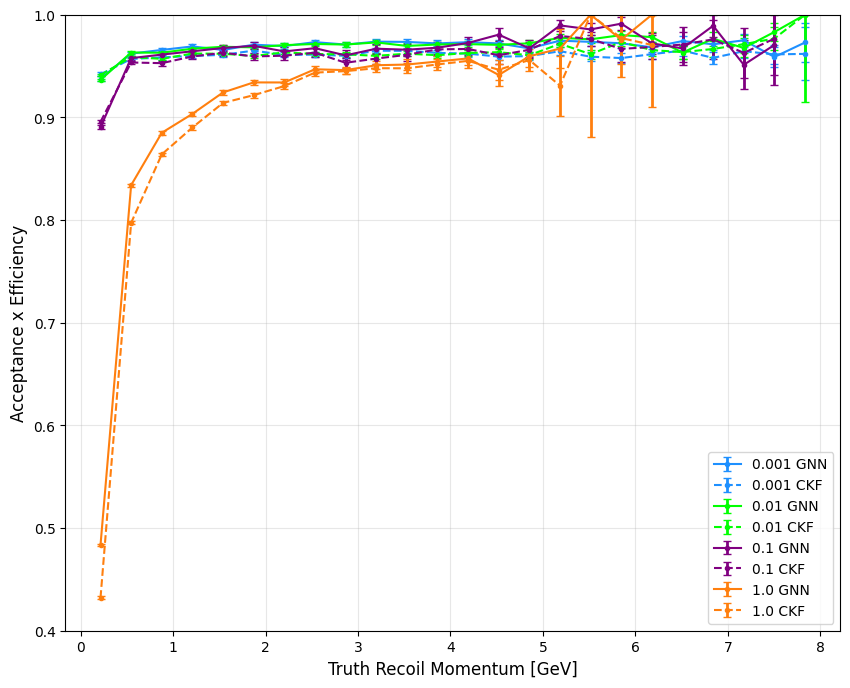

In [ ]:
# Create the plot
plt.figure(figsize=(10, 8))
plt.errorbar(np.array(P_centers_all[0])/1000, Track_effs_all[0], yerr=Track_eff_errs_all[0],
             color = 'dodgerblue',
             fmt='-o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.001 GNN')
plt.errorbar(df_0pt001.momentum_center, df_0pt001.acc_times_eff, yerr=df_0pt001.error_low,
             color = 'dodgerblue',
             fmt='--o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.001 CKF')
plt.errorbar(np.array(P_centers_all[1])/1000, Track_effs_all[1], yerr=Track_eff_errs_all[1],
             color = 'lime',
             fmt='-o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.01 GNN')
plt.errorbar(df_0pt01.momentum_center, df_0pt01.acc_times_eff, yerr=df_0pt01.error_low,
             color = 'lime',
             fmt='--o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.01 CKF')
plt.errorbar(np.array(P_centers_all[2])/1000, Track_effs_all[2], yerr=Track_eff_errs_all[2],
             color = 'purple',
             fmt='-o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.1 GNN')
plt.errorbar(df_0pt1.momentum_center, df_0pt1.acc_times_eff, yerr=df_0pt1.error_low,
             color = 'purple',
             fmt='--o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.1 CKF')
plt.errorbar(np.array(P_centers_all[3])/1000, Track_effs_all[3], yerr=Track_eff_errs_all[3],
             color = 'tab:orange',
             fmt='-o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='1.0 GNN')
plt.errorbar(df_1pt0.momentum_center, df_1pt0.acc_times_eff, yerr=df_1pt0.error_low,
             color = 'tab:orange',
             fmt='--o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='1.0 CKF')
# Customize the plot
plt.xlabel('Truth Recoil Momentum [GeV]', fontsize=12)
plt.ylabel('Acceptance x Efficiency', fontsize=12)
plt.ylim(0.4,1.0)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

Text(0, 0.5, 'Counts')

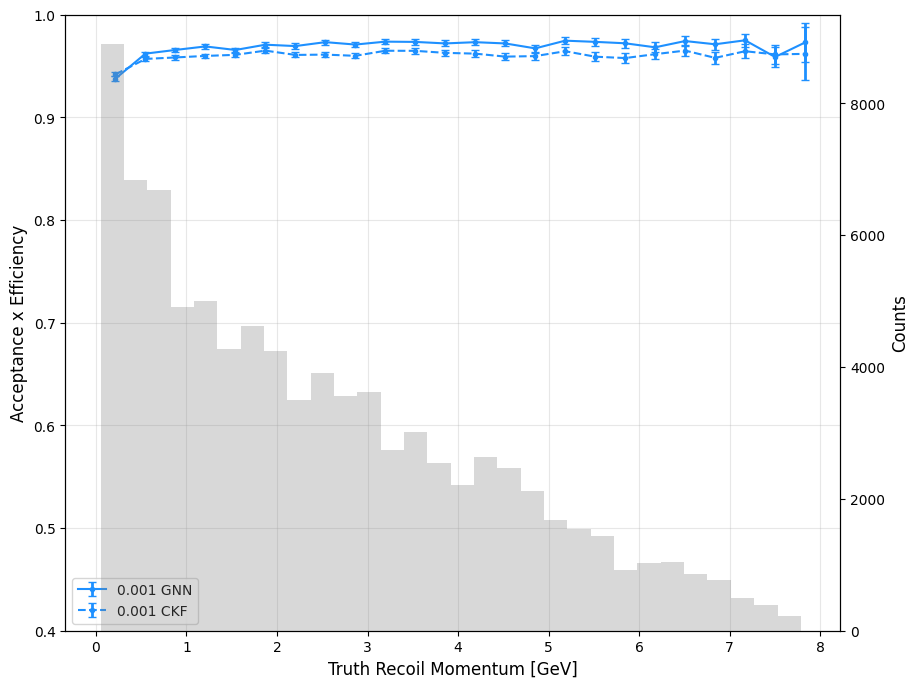

In [ ]:
in_dir = '/content/drive/MyDrive/LDMX_GNN/data/signal_processed/test/signal_Ap'+str(0.001)+'GeV_1e_processed/'
df = GTT.load_pickle_files_to_dataframe(in_dir)
df['SignalID'] = df.apply(GTT.get_signal_recoilID, axis=1)
df['TruthP'] = df.apply(GTT.get_signal_recoilP, axis=1)
df = df.loc[df.TruthP > 50]
df['TruthP'] = df['TruthP']/1000

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 8))

# First y-axis (Acceptance x Efficiency)
ax1.errorbar(np.array(P_centers_all[0])/1000, Track_effs_all[0], yerr=Track_eff_errs_all[0],
             color = 'dodgerblue',
             fmt='-o',
             markersize=3,
             capsize=3,
             capthick=1,
             elinewidth=2,
             label='0.001 GNN')
ax1.errorbar(df_0pt001.momentum_center, df_0pt001.acc_times_eff, yerr=df_0pt001.error_low,
             color = 'dodgerblue',
             fmt='--o',
             markersize=3,
             capsize=3,
             capthick=1,
             elinewidth=2,
             label='0.001 CKF')

ax1.set_xlabel('Truth Recoil Momentum [GeV]', fontsize=12)
ax1.set_ylabel('Acceptance x Efficiency', fontsize=12)
ax1.set_ylim(0.4, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# # Second y-axis (for histogram)
ax2 = ax1.twinx()
ax2.hist(df['TruthP'], bins=30, alpha=0.3, color='gray')
ax2.set_ylabel('Counts', fontsize=12)

In [ ]:
in_dir = '/content/drive/MyDrive/LDMX_GNN/data/signal_processed/test/signal_Ap'+str(0.01)+'GeV_1e_processed/'
df = GTT.load_pickle_files_to_dataframe(in_dir)
df['SignalID'] = df.apply(GTT.get_signal_recoilID, axis=1)
df['TruthP'] = df.apply(GTT.get_signal_recoilP, axis=1)
df = df.loc[df.TruthP > 50]
df['TruthP'] = df['TruthP']/1000

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 8))

# First y-axis (Acceptance x Efficiency)
plt.errorbar(np.array(P_centers_all[1])/1000, Track_effs_all[1], yerr=Track_eff_errs_all[1],
             color = 'lime',
             fmt='-o',
             markersize=3,
             capsize=3,
             capthick=1,
             elinewidth=2,
             label='0.01 GNN')
plt.errorbar(df_0pt01.momentum_center, df_0pt01.acc_times_eff, yerr=df_0pt01.error_low,
             color = 'lime',
             fmt='--o',
             markersize=3,
             capsize=3,
             capthick=1,
             elinewidth=2,
             label='0.01 CKF')

ax1.set_xlabel('Truth Recoil Momentum [GeV]', fontsize=12)
ax1.set_ylabel('Acceptance x Efficiency', fontsize=12)
ax1.set_ylim(0.4, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# # Second y-axis (for histogram)
ax2 = ax1.twinx()
ax2.hist(df['TruthP'], bins=30, alpha=0.3, color='gray')
ax2.set_ylabel('Counts', fontsize=12)

Text(0, 0.5, 'Counts')

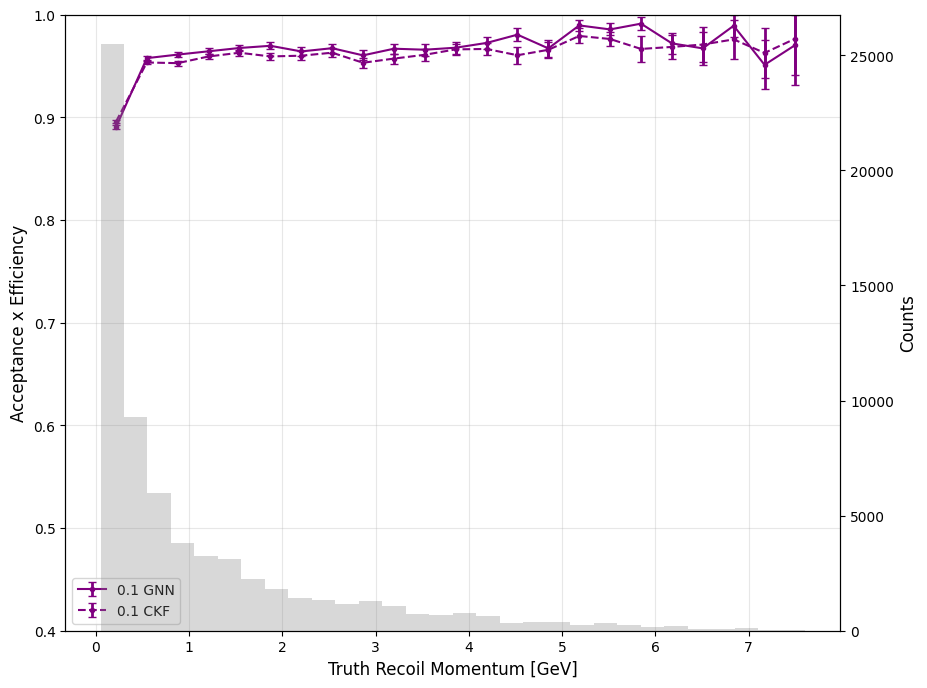

In [ ]:
in_dir = '/content/drive/MyDrive/LDMX_GNN/data/signal_processed/test/signal_Ap'+str(0.1)+'GeV_1e_processed/'
df = GTT.load_pickle_files_to_dataframe(in_dir)
df['SignalID'] = df.apply(GTT.get_signal_recoilID, axis=1)
df['TruthP'] = df.apply(GTT.get_signal_recoilP, axis=1)
df = df.loc[df.TruthP > 50]
df['TruthP'] = df['TruthP']/1000

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 8))

# First y-axis (Acceptance x Efficiency)
plt.errorbar(np.array(P_centers_all[2])/1000, Track_effs_all[2], yerr=Track_eff_errs_all[2],
             color = 'purple',
             fmt='-o',
             markersize=3,
             capsize=3,
             capthick=1,
             elinewidth=2,
             label='0.1 GNN')
plt.errorbar(df_0pt1.momentum_center, df_0pt1.acc_times_eff, yerr=df_0pt1.error_low,
             color = 'purple',
             fmt='--o',
             markersize=3,
             capsize=3,
             capthick=1,
             elinewidth=2,
             label='0.1 CKF')

ax1.set_xlabel('Truth Recoil Momentum [GeV]', fontsize=12)
ax1.set_ylabel('Acceptance x Efficiency', fontsize=12)
ax1.set_ylim(0.4, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# # Second y-axis (for histogram)
ax2 = ax1.twinx()
ax2.hist(df['TruthP'], bins=30, alpha=0.3, color='gray')
ax2.set_ylabel('Counts', fontsize=12)

In [ ]:
in_dir = '/content/drive/MyDrive/LDMX_GNN/data/signal_processed/test/signal_Ap'+str(1.0)+'GeV_1e_processed/'
df = GTT.load_pickle_files_to_dataframe(in_dir)
df['SignalID'] = df.apply(GTT.get_signal_recoilID, axis=1)
df['TruthP'] = df.apply(GTT.get_signal_recoilP, axis=1)
df = df.loc[df.TruthP > 50]
df['TruthP'] = df['TruthP']/1000

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 8))

# First y-axis (Acceptance x Efficiency)
plt.errorbar(np.array(P_centers_all[3])/1000, Track_effs_all[3], yerr=Track_eff_errs_all[3],
             color = 'tab:orange',
             fmt='-o',
             markersize=3,
             capsize=3,
             capthick=1,
             elinewidth=2,
             label='1.0 GNN')
plt.errorbar(df_1pt0.momentum_center, df_1pt0.acc_times_eff, yerr=df_1pt0.error_low,
             color = 'tab:orange',
             fmt='--o',
             markersize=3,
             capsize=3,
             capthick=1,
             elinewidth=2,
             label='1.0 CKF')
plt.plot(np.array(P_centers_all[3])/1000, best_all[3],
         color = 'tab:orange',
         linestyle=':',
         marker='o',
         markersize=3,
         label='1.0 Best possible')

ax1.set_xlabel('Truth Recoil Momentum [GeV]', fontsize=12)
ax1.set_ylabel('Acceptance x Efficiency', fontsize=12)
ax1.set_ylim(0.4, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# # Second y-axis (for histogram)
ax2 = ax1.twinx()
ax2.hist(df['TruthP'], bins=30, alpha=0.3, color='gray')
ax2.set_ylabel('Counts', fontsize=12)

In [ ]:
import pickle, os

plot_data = {
    "P_centers": np.array(P_centers_all[3]) / 1000,  # GeV
    "Track_effs": np.array(Track_effs_all[3]),
    "Track_eff_errs": np.array(Track_eff_errs_all[3]),
    "best_effs": np.array(best_all[3]),
    "TruthP": df["TruthP"].values,  # already in GeV, TruthP > 50 MeV filter applied
    "ckf_csv": os.path.expanduser("/content/drive/MyDrive/LDMX_GNN/results/CKF_signal/momentum_mAp_3.csv"),
}

out_path = os.path.expanduser('/content/drive/MyDrive/LDMX_GNN/results/IN_amb_signal_1pt0GeV_plot_data.pkl')
with open(out_path, "wb") as f:
    pickle.dump(plot_data, f)
print(f"Saved to {out_path}")

In [ ]:
print ( "0.001 Overall fake rate : ", np.sum(dfs[0].num_GNN_Tracks - dfs[0].matched_tracks) / len(dfs[0]) )
print ( "0.01 Overall fake rate : ", np.sum(dfs[1].num_GNN_Tracks - dfs[1].matched_tracks) / len(dfs[1]) )
print ( "0.1 Overall fake rate : ", np.sum(dfs[2].num_GNN_Tracks - dfs[2].matched_tracks) / len(dfs[2]) )
print ( "1.0 Overall fake rate : ", np.sum(dfs[3].num_GNN_Tracks - dfs[3].matched_tracks) / len(dfs[3]) )
